In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Задание 1.1
def calculate_entropy(class_counts):
    """
    Расчет энтропии с натуральным логарифмом
    """
    total = sum(class_counts)
    probabilities = [count/total for count in class_counts]
    entropy = -sum(p * np.log(p) for p in probabilities if p > 0)
    return entropy

# Данные: 8 объектов класса k1, 2 объекта класса k2
class_counts = [8, 2]
entropy_value = calculate_entropy(class_counts)
print(f"Энтропия: {entropy_value:.2f}")

Энтропия: 0.50


In [ ]:
#задание 1.2
def gini_index(class_counts):
    """
    Расчет индекса Джини
    """
    total = sum(class_counts)
    if total == 0:
        return 0
    probabilities = [count/total for count in class_counts]
    gini = 1 - sum(p**2 for p in probabilities)
    return gini

# Исходная вершина
R_m = [8, 2]  # 8 класса k1, 2 класса k2
H_Rm = gini_index(R_m)

# После разбиения: левое поддерево - все k1, правое - все k2
R_l = [8, 0]  # все объекты класса k1
R_r = [0, 2]  # все объекты класса k2

H_Rl = gini_index(R_l)
H_Rr = gini_index(R_r)

# Критерий информативности
Q = H_Rm - (len(R_l)/sum(R_m)) * H_Rl - (len(R_r)/sum(R_m)) * H_Rr
print(f"Критерий информативности: {Q:.2f}")

Критерий информативности: 0.32


In [ ]:
#задание 1.3
# Данные для регрессии
values = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]

# В задаче регрессии предсказанием в листе будет среднее значение
prediction = np.mean(values)
print(f"Предсказание для всех объектов: {prediction}")

Предсказание для всех объектов: 40.6


In [ ]:

from typing import Union, Tuple
import matplotlib.pyplot as plt

def gini_index(class_counts: np.ndarray) -> float:
    """
    Расчет индекса Джини для классификации
    """
    total = np.sum(class_counts)
    if total == 0:
        return 0
    probabilities = class_counts / total
    return 1 - np.sum(probabilities ** 2)

def find_best_split(
    feature_vector: Union[np.ndarray, pd.Series],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:

    # Проверка на константный признак
    unique_values = np.unique(feature_vector)
    if len(unique_values) <= 1:
        return np.array([]), np.array([]), 0, -np.inf

    if feature_type == "real":
        # Сортируем значения признака
        sorted_idx = np.argsort(feature_vector)
        sorted_features = feature_vector[sorted_idx]

        # Находим пороги как средние между соседними значениями
        thresholds = (sorted_features[1:] + sorted_features[:-1]) / 2
        # Берем только уникальные пороги
        thresholds = np.unique(thresholds)

        gains = []

        for threshold in thresholds:
            left_mask = feature_vector <= threshold
            right_mask = ~left_mask

            # Пропускаем пороги, создающие пустые поддеревья
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                gains.append(-np.inf)
                continue

            if task == "classification":
                # Расчет для классификации (индекс Джини)
                left_counts = np.bincount(target_vector[left_mask])
                right_counts = np.bincount(target_vector[right_mask])
                parent_counts = np.bincount(target_vector)

                gini_left = gini_index(left_counts)
                gini_right = gini_index(right_counts)
                gini_parent = gini_index(parent_counts)

                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                n_total = len(target_vector)

                weighted_gini = (n_left/n_total * gini_left + n_right/n_total * gini_right)
                gain = gini_parent - weighted_gini

            else:
                # Расчет для регрессии (дисперсия)
                var_left = np.var(target_vector[left_mask])
                var_right = np.var(target_vector[right_mask])
                var_parent = np.var(target_vector)

                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                n_total = len(target_vector)

                weighted_var = (n_left/n_total * var_left + n_right/n_total * var_right)
                gain = var_parent - weighted_var

            gains.append(gain)

        gains = np.array(gains)

        # Находим лучший порог
        if len(gains) > 0 and np.max(gains) > -np.inf:
            best_idx = np.argmax(gains)
            return thresholds, gains, thresholds[best_idx], gains[best_idx]
        else:
            return np.array([]), np.array([]), 0, -np.inf

    else:  # categorical feature
        categories = np.unique(feature_vector)
        gains = []

        for category in categories:
            left_mask = feature_vector == category
            right_mask = ~left_mask

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                gains.append(-np.inf)
                continue

            if task == "classification":
                left_counts = np.bincount(target_vector[left_mask])
                right_counts = np.bincount(target_vector[right_mask])
                parent_counts = np.bincount(target_vector)

                gini_left = gini_index(left_counts)
                gini_right = gini_index(right_counts)
                gini_parent = gini_index(parent_counts)

                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                n_total = len(target_vector)

                weighted_gini = (n_left/n_total * gini_left + n_right/n_total * gini_right)
                gain = gini_parent - weighted_gini

            else:
                var_left = np.var(target_vector[left_mask])
                var_right = np.var(target_vector[right_mask])
                var_parent = np.var(target_vector)

                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                n_total = len(target_vector)

                weighted_var = (n_left/n_total * var_left + n_right/n_total * var_right)
                gain = var_parent - weighted_var

            gains.append(gain)

        gains = np.array(gains)

        if len(gains) > 0 and np.max(gains) > -np.inf:
            best_idx = np.argmax(gains)
            return categories, gains, categories[best_idx], gains[best_idx]
        else:
            return np.array([]), np.array([]), 0, -np.inf

Первые 5 строк данных:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Целевая переменная (первые 10 значений): [4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]

Анализ признака MedInc:
Найдено порогов: 16161
Лучший порог: 5.0351
Лучший информационный gain: 0.4128


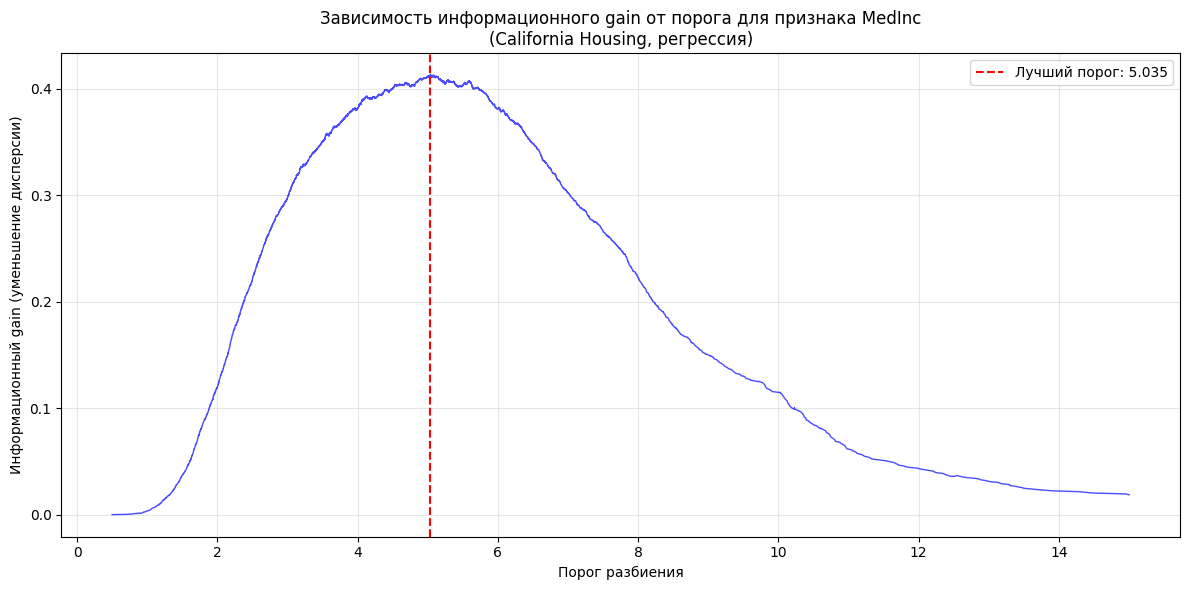

In [ ]:
from sklearn.datasets import fetch_california_housing

# Загрузка данных
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]

print("Первые 5 строк данных:")
print(X.head())
print(f"\nЦелевая переменная (первые 10 значений): {y[:10]}")

# Анализ признака MedInc
print(f"\nАнализ признака MedInc:")
feature_vector = X['MedInc'].values

# Находим лучшее разбиение для регрессии
thresholds, gains, best_threshold, best_gain = find_best_split(
    feature_vector, y, task="regression", feature_type="real"
)

print(f"Найдено порогов: {len(thresholds)}")
print(f"Лучший порог: {best_threshold:.4f}")
print(f"Лучший информационный gain: {best_gain:.4f}")

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(thresholds, gains, 'b-', alpha=0.7, linewidth=1)
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Лучший порог: {best_threshold:.3f}')
plt.xlabel('Порог разбиения')
plt.ylabel('Информационный gain (уменьшение дисперсии)')
plt.title('Зависимость информационного gain от порога для признака MedInc\n(California Housing, регрессия)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Поиск лучшего признака для первой вершины
print("Поиск лучшего признака для первой вершины решающего дерева:")
print("-" * 60)

best_feature_name = None
best_feature_gain = -np.inf
best_feature_threshold = 0

for feature_name in X.columns:
    feature_vector = X[feature_name].values
    _, _, threshold, gain = find_best_split(
        feature_vector, y, task="regression", feature_type="real"
    )

    print(f"{feature_name:15} | gain: {gain:10.4f} | порог: {threshold:8.4f}")

    if gain > best_feature_gain:
        best_feature_gain = gain
        best_feature_name = feature_name
        best_feature_threshold = threshold

print("-" * 60)
print(f"🎯 ЛУЧШИЙ ПРИЗНАК: '{best_feature_name}'")
print(f"   Оптимальный порог: {best_feature_threshold:.4f}")
print(f"   Информационный gain: {best_feature_gain:.4f}")
print(f"   Предикат: if {best_feature_name} <= {best_feature_threshold:.4f}")

Поиск лучшего признака для первой вершины решающего дерева:
------------------------------------------------------------
MedInc          | gain:     0.4128 | порог:   5.0351
HouseAge        | gain:     0.0309 | порог:  51.0000
AveRooms        | gain:     0.1592 | порог:   6.3743
AveBedrms       | gain:     0.0153 | порог:   1.1034
Population      | gain:     0.0028 | порог: 1160.0000
AveOccup        | gain:     0.0739 | порог:   3.1125
Latitude        | gain:     0.0903 | порог:  37.9300
Longitude       | gain:     0.0502 | порог: -121.8700
------------------------------------------------------------
🎯 ЛУЧШИЙ ПРИЗНАК: 'MedInc'
   Оптимальный порог: 5.0351
   Информационный gain: 0.4128
   Предикат: if MedInc <= 5.0351


In [ ]:
#задание 2.2
from collections import Counter
from typing import Dict, List, Tuple, Union
import numpy as np

class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        self._feature_importances = {}
        self._depth = 0

    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict,
        depth: int = 0
    ) -> None:

        # Критерии останова
        stop_condition = (
            # Все объекты одного класса
            np.all(sub_y == sub_y[0]) or
            # Достигнута максимальная глубина
            (self._max_depth is not None and depth >= self._max_depth) or
            # Слишком мало объектов для разделения
            (self._min_samples_split is not None and len(sub_y) < self._min_samples_split)
        )

        if stop_condition:
            node["type"] = "terminal"
            if self.task == "classification":
                node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:  # regression
                node["class"] = np.mean(sub_y)
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                feature_vector = sub_X[:, feature]

            # Ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini is not None and gini > -np.inf and (gini_best is None or gini > gini_best):
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector <= threshold_best
                elif feature_type == "categorical":
                    threshold_best = threshold
                    split = feature_vector == threshold_best

        # Проверяем, что нашли хорошее разбиение и выполняются условия min_samples_leaf
        if (feature_best is None or
            (self._min_samples_leaf is not None and
             (np.sum(split) < self._min_samples_leaf or
              np.sum(~split) < self._min_samples_leaf))):
            node["type"] = "terminal"
            if self.task == "classification":
                node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:
                node["class"] = np.mean(sub_y)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best

        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}

        # Рекурсивно обучаем поддеревья
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth + 1)
        self._fit_node(sub_X[~split], sub_y[~split], node["right_child"], depth + 1)

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание для одного объекта
        """
        if node["type"] == "terminal":
            return node["class"]

        feature_idx = node["feature_split"]
        feature_type = self._feature_types[feature_idx]

        if feature_type == "real":
            if x[feature_idx] <= node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:  # categorical
            if x[feature_idx] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._tree = {}
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

Информация о датасете students:
Размер: (258, 7)
Признаки: ['Unnamed: 0', 'STG', 'SCG', 'STR', 'LPR', 'PEG']
Распределение классов: Counter({1: 151, 0: 107})


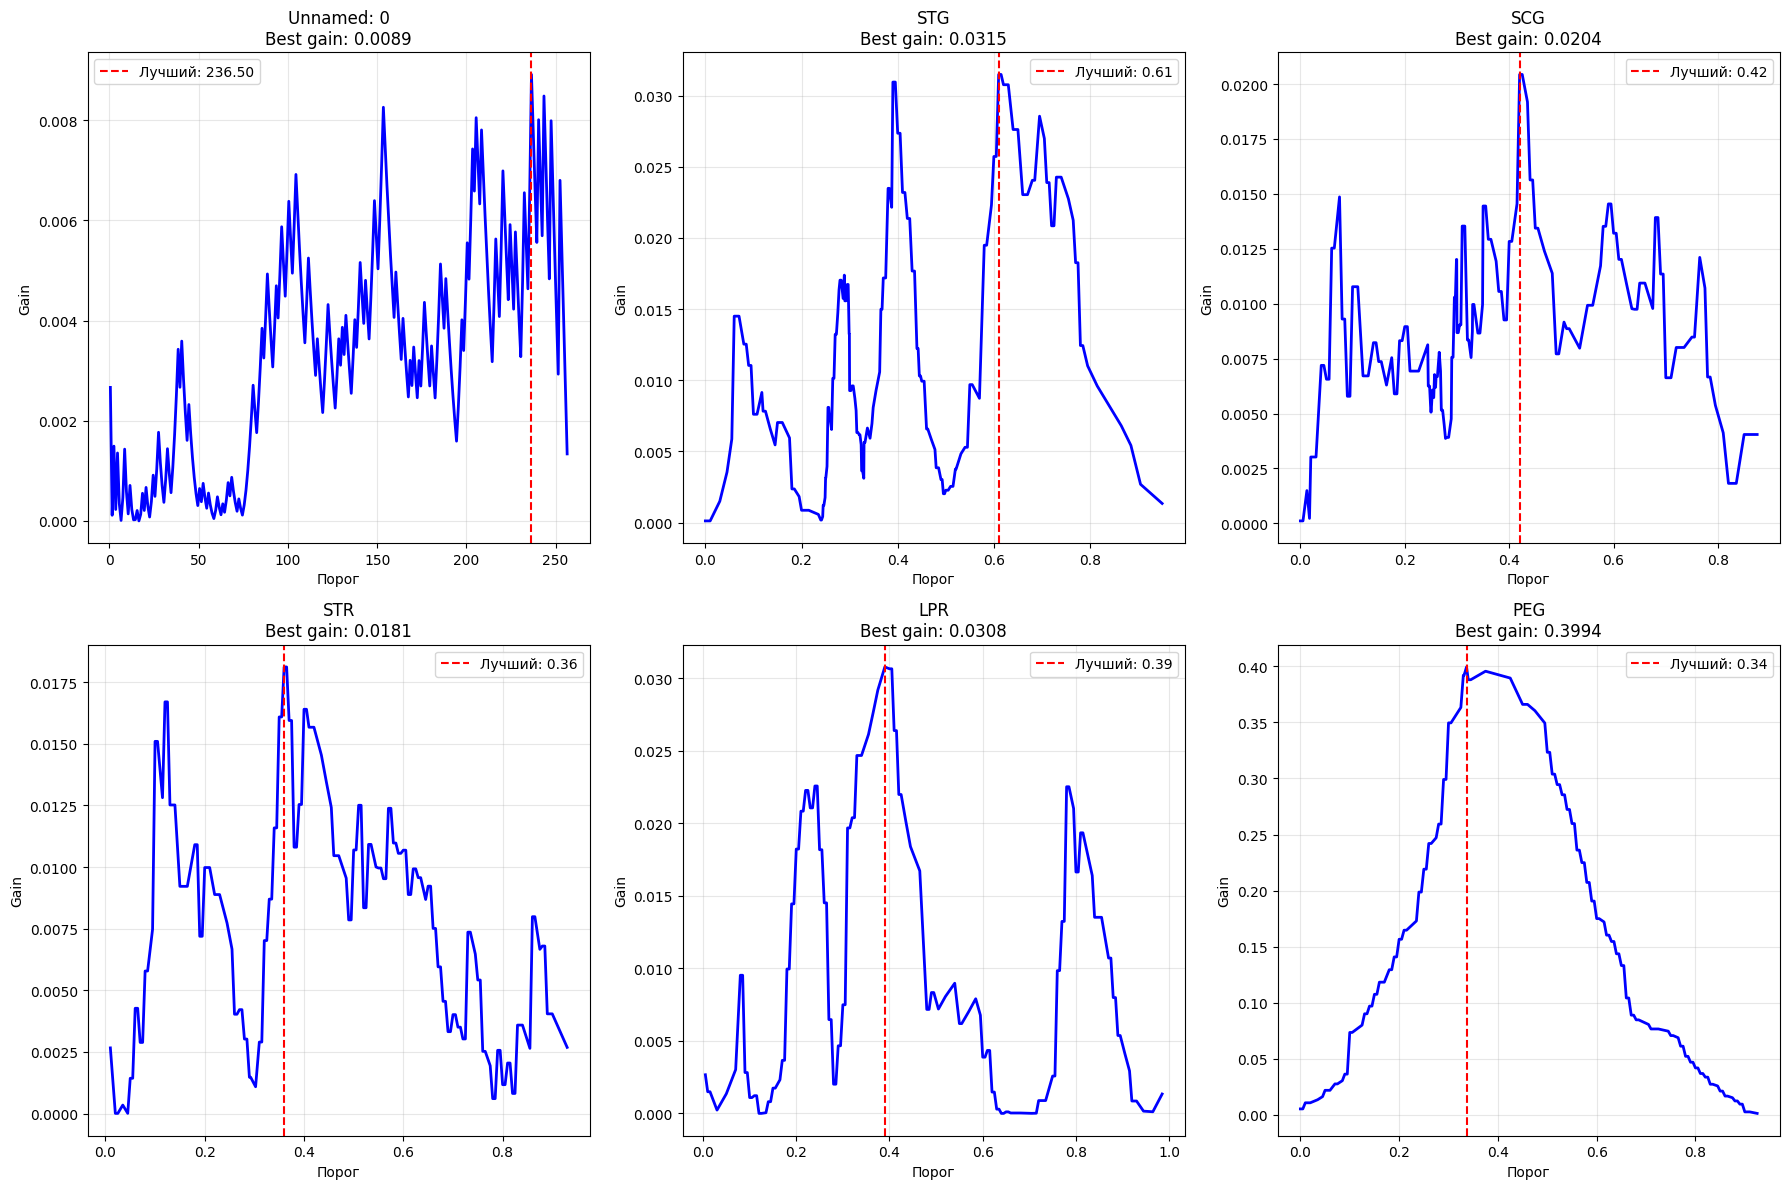

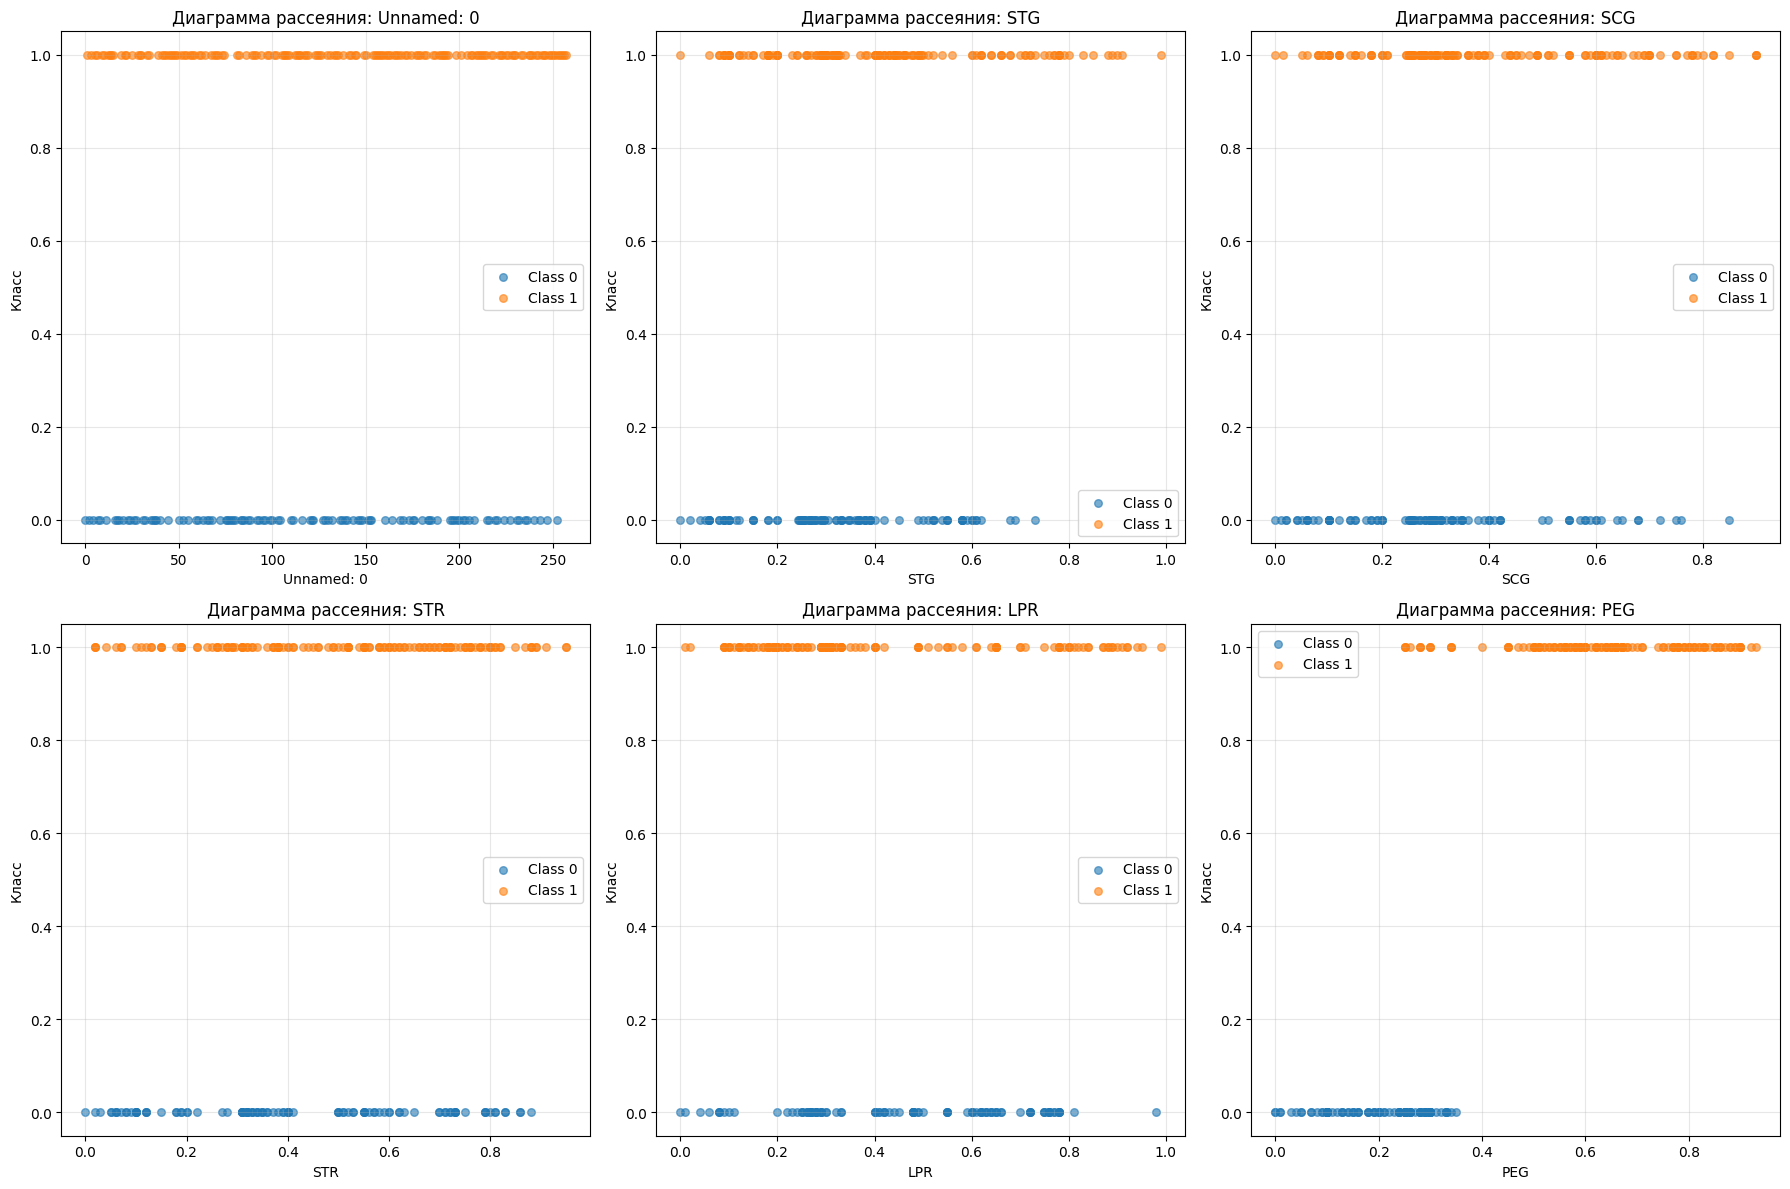


Анализ результатов:
Unnamed: 0: gain = 0.0089
STG: gain = 0.0315
SCG: gain = 0.0204
STR: gain = 0.0181
LPR: gain = 0.0308
PEG: gain = 0.3994

Лучший признак для разбиения: PEG
С gain = 0.3994


In [ ]:
# Задание 2.3
import matplotlib.pyplot as plt

# Загрузка данных students.csv
students_data = pd.read_csv('/students.csv')
X_students = students_data.iloc[:, :-1]
y_students = students_data.iloc[:, -1]

print("Информация о датасете students:")
print(f"Размер: {students_data.shape}")
print(f"Признаки: {list(X_students.columns)}")
print(f"Распределение классов: {Counter(y_students)}")

# Построение графиков критерия Джини для всех признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature_name in enumerate(X_students.columns):
    feature_vector = X_students[feature_name].values

    thresholds, ginis, best_threshold, best_gini = find_best_split(
        feature_vector, y_students, task="classification", feature_type="real"
    )

    if len(thresholds) > 0:
        axes[i].plot(thresholds, ginis, 'b-', linewidth=2)
        axes[i].axvline(x=best_threshold, color='red', linestyle='--',
                       label=f'Лучший: {best_threshold:.2f}')
        axes[i].set_title(f'{feature_name}\nBest gain: {best_gini:.4f}')
        axes[i].set_xlabel('Порог')
        axes[i].set_ylabel('Gain')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, 'Нет разбиений', ha='center', va='center')
        axes[i].set_title(feature_name)

# Убираем лишний subplot
if len(X_students.columns) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Диаграммы рассеяния
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature_name in enumerate(X_students.columns):
    for class_val in [0, 1]:
        mask = y_students == class_val
        axes[i].scatter(X_students[feature_name][mask], [class_val] * np.sum(mask),
                       alpha=0.6, s=30, label=f'Class {class_val}')

    axes[i].set_title(f'Диаграмма рассеяния: {feature_name}')
    axes[i].set_xlabel(feature_name)
    axes[i].set_ylabel('Класс')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

if len(X_students.columns) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Анализ результатов
print("\nАнализ результатов:")
best_feature_idx = None
best_gain = -np.inf

for i, feature_name in enumerate(X_students.columns):
    feature_vector = X_students[feature_name].values
    _, _, _, gain = find_best_split(feature_vector, y_students, "classification", "real")

    if gain > best_gain:
        best_gain = gain
        best_feature_idx = i

    print(f"{feature_name}: gain = {gain:.4f}")

print(f"\nЛучший признак для разбиения: {X_students.columns[best_feature_idx]}")
print(f"С gain = {best_gain:.4f}")

In [ ]:
#задание 2.4
# %% [code]
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Считываем данные
data = pd.read_csv('/content/agaricus-lepiota.data', header=None)

# Применяем LabelEncoder к каждому столбцу
label_encoders = {}
data_encoded = data.copy()

for column in data.columns:
    le = LabelEncoder()
    data_encoded[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Разделяем на признаки и целевую переменную
# Первый столбец - целевая переменная
X = data_encoded.iloc[:, 1:]  # все столбцы кроме первого
y = data_encoded.iloc[:, 0]   # первый столбец - целевая переменная

# Разделяем данные на обучающую и тестовую выборки (50/50)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# Создаем и обучаем решающее дерево
tree_classifier = DecisionTreeClassifier(random_state=42)
tree_classifier.fit(X_train, y_train)

# Делаем предсказания на тестовой выборке
y_pred = tree_classifier.predict(X_test)

# Вычисляем accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Дополнительная информация о данных
print(f"\nИнформация о данных:")
print(f"Размер исходного датасета: {data.shape}")
print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Количество признаков: {X_train.shape[1]}")
print(f"Классы целевой переменной: {label_encoders[0].classes_}")

Accuracy: 1.0000

Информация о данных:
Размер исходного датасета: (8124, 23)
Обучающая выборка: 4062 объектов
Тестовая выборка: 4062 объектов
Количество признаков: 22
Классы целевой переменной: ['e' 'p']


In [ ]:
#часть 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
# Загрузка данных
data = pd.read_csv('/content/diabetes (1).csv')
print(f"Dataset shape: {data.shape}")
data.head()


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


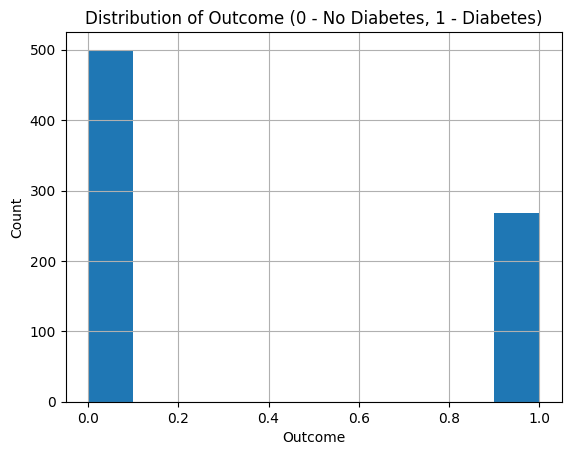

In [ ]:
# %% [code]
# Распределение целевой переменной
data['Outcome'].hist()
plt.title('Distribution of Outcome (0 - No Diabetes, 1 - Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

In [ ]:

# Задание 3.1 - Разделение данных
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Первое разделение: 70% train, 30% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Второе разделение: 70% train_train, 30% train_val от исходного train
X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42, stratify=y_train_full
)

print(f"Исходный датасет: {X.shape[0]} samples")
print(f"Обучающая-обучающая: {X_train_train.shape[0]} samples ({X_train_train.shape[0]/X.shape[0]:.2%})")
print(f"Обучающая-валидационная: {X_train_val.shape[0]} samples ({X_train_val.shape[0]/X.shape[0]:.2%})")
print(f"Тестовая: {X_test.shape[0]} samples ({X_test.shape[0]/X.shape[0]:.2%})")

Исходный датасет: 768 samples
Обучающая-обучающая: 375 samples (48.83%)
Обучающая-валидационная: 162 samples (21.09%)
Тестовая: 231 samples (30.08%)


In [ ]:

# Задание 3.2 - Подбор гиперпараметров для Decision Tree
max_depth_list = [3, 5, 7, 10, 15, 20, None]
min_samples_leaf_list = [1, 2, 5, 10, 15, 20]

best_f1 = 0
best_params = {}

for max_depth in max_depth_list:
    for min_samples_leaf in min_samples_leaf_list:
        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        tree.fit(X_train_train, y_train_train)
        y_pred_val = tree.predict(X_train_val)
        f1 = f1_score(y_train_val, y_pred_val)

        if f1 > best_f1:
            best_f1 = f1
            best_params = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf}

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая F1-score на валидации: {best_f1:.4f}")

# Обучение на полной обучающей выборке с лучшими параметрами
best_tree = DecisionTreeClassifier(**best_params, random_state=42)
best_tree.fit(X_train_full, y_train_full)

# Предсказания на тестовой выборке
y_pred_tree = best_tree.predict(X_test)
y_pred_proba_tree = best_tree.predict_proba(X_test)[:, 1]

# Метрики
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_pred_proba_tree)

print("\nРешающее дерево на тестовой выборке:")
print(f"Accuracy: {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall: {recall_tree:.4f}")
print(f"AUC ROC: {auc_tree:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 20}
Лучшая F1-score на валидации: 0.6250

Решающее дерево на тестовой выборке:
Accuracy: 0.7273
Precision: 0.6452
Recall: 0.4938
AUC ROC: 0.7951


In [ ]:

# Задание 3.3 - BaggingClassifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train_full, y_train_full)

y_pred_bagging = bagging.predict(X_test)
y_pred_proba_bagging = bagging.predict_proba(X_test)[:, 1]

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
auc_bagging = roc_auc_score(y_test, y_pred_proba_bagging)

print("BaggingClassifier на тестовой выборке:")
print(f"Accuracy: {accuracy_bagging:.4f}")
print(f"Precision: {precision_bagging:.4f}")
print(f"Recall: {recall_bagging:.4f}")
print(f"AUC ROC: {auc_bagging:.4f}")

BaggingClassifier на тестовой выборке:
Accuracy: 0.7532
Precision: 0.6875
Recall: 0.5432
AUC ROC: 0.8269


In [ ]:

# Задание 3.4 - Random Forest с подбором гиперпараметров
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15]
}

rf = RandomForestClassifier(n_estimators=50, random_state=42)
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_full, y_train_full)

print(f"Лучшие параметры для Random Forest: {grid_search.best_params_}")
print(f"Лучший F1-score: {grid_search.best_score_:.4f}")

# Обучение лучшей модели на полной обучающей выборке
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nRandom Forest на тестовой выборке:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"AUC ROC: {auc_rf:.4f}")

# Сравнение моделей
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ:")
print("="*50)
print(f"Decision Tree - AUC: {auc_tree:.4f}, Accuracy: {accuracy_tree:.4f}")
print(f"Bagging       - AUC: {auc_bagging:.4f}, Accuracy: {accuracy_bagging:.4f}")
print(f"Random Forest - AUC: {auc_rf:.4f}, Accuracy: {accuracy_rf:.4f}")

Лучшие параметры для Random Forest: {'max_depth': 20, 'min_samples_split': 10}
Лучший F1-score: 0.6334

Random Forest на тестовой выборке:
Accuracy: 0.7403
Precision: 0.6567
Recall: 0.5432
AUC ROC: 0.8207

СРАВНЕНИЕ МОДЕЛЕЙ:
Decision Tree - AUC: 0.7951, Accuracy: 0.7273
Bagging       - AUC: 0.8269, Accuracy: 0.7532
Random Forest - AUC: 0.8207, Accuracy: 0.7403


n_estimators: 10, AUC: 0.7793
n_estimators: 20, AUC: 0.8056
n_estimators: 30, AUC: 0.8185
n_estimators: 40, AUC: 0.8216
n_estimators: 50, AUC: 0.8207
n_estimators: 75, AUC: 0.8205
n_estimators: 100, AUC: 0.8187
n_estimators: 150, AUC: 0.8222
n_estimators: 200, AUC: 0.8253


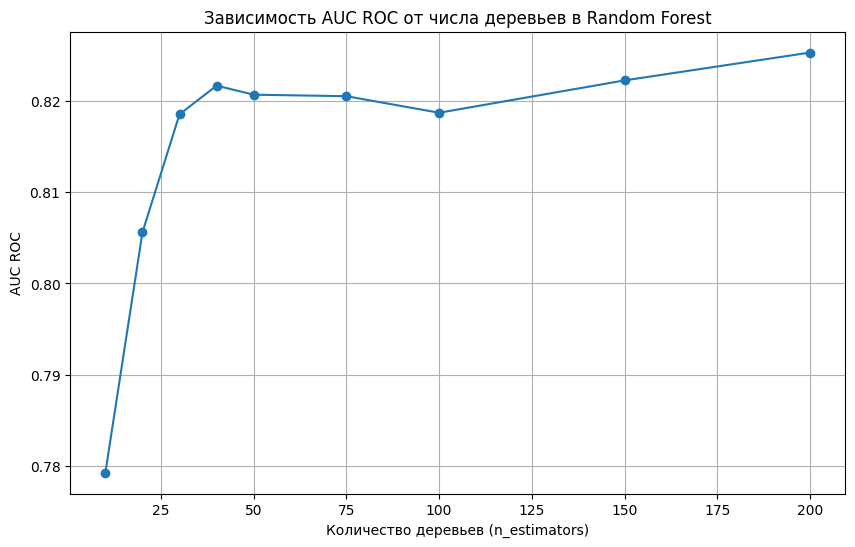

Лучшее количество деревьев: 200 с AUC: 0.8253


In [ ]:

# Задание 3.5 - График зависимости AUC ROC от числа деревьев
n_estimators_list = [10, 20, 30, 40, 50, 75, 100, 150, 200]
auc_scores = []

for n_est in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        random_state=42
    )
    rf_temp.fit(X_train_full, y_train_full)
    y_pred_proba_temp = rf_temp.predict_proba(X_test)[:, 1]
    auc_temp = roc_auc_score(y_test, y_pred_proba_temp)
    auc_scores.append(auc_temp)
    print(f"n_estimators: {n_est}, AUC: {auc_temp:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, auc_scores, marker='o')
plt.title('Зависимость AUC ROC от числа деревьев в Random Forest')
plt.xlabel('Количество деревьев (n_estimators)')
plt.ylabel('AUC ROC')
plt.grid(True)
plt.show()

# Анализ результатов
best_n_estimators = n_estimators_list[np.argmax(auc_scores)]
print(f"Лучшее количество деревьев: {best_n_estimators} с AUC: {max(auc_scores):.4f}")

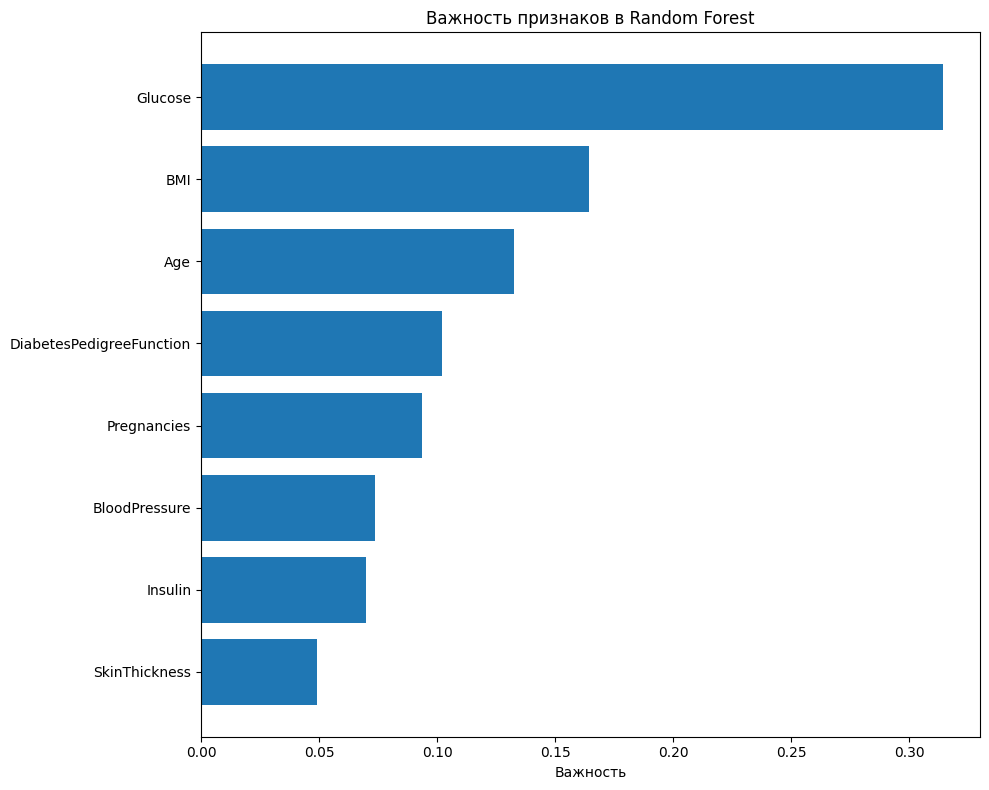

Самый важный признак: 'Glucose' с важностью 0.3142

Все признаки по убыванию важности:
Glucose: 0.3142
BMI: 0.1645
Age: 0.1327
DiabetesPedigreeFunction: 0.1023
Pregnancies: 0.0936
BloodPressure: 0.0736
Insulin: 0.0699
SkinThickness: 0.0493


In [ ]:

# Задание 3.6 - Важность признаков для лучшей модели Random Forest
feature_importances = best_rf.feature_importances_
feature_names = X.columns

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=True)

# Строим bar plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Важность признаков в Random Forest')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Выводим самый важный признак
most_important_feature = importance_df.iloc[-1]
print(f"Самый важный признак: '{most_important_feature['feature']}' с важностью {most_important_feature['importance']:.4f}")

# Выводим все признаки по убыванию важности
print("\nВсе признаки по убыванию важности:")
for i, row in importance_df.iloc[::-1].iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")